In [31]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [32]:
df=pd.read_csv('cs-training.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [33]:
print(df.head())

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

In [34]:
df=df.drop(['Unnamed: 0'],axis=1)

In [35]:
print(df.head())

   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0                 1                              0.766127   45   
1                 0                              0.957151   40   
2                 0                              0.658180   38   
3                 0                              0.233810   30   
4                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                        0   
1                                4                        0   

In [36]:
for col in df.columns:
    print(f"{col} description:\n {df[col].describe()}\n{'-'*50}")

SeriousDlqin2yrs description:
 count    150000.000000
mean          0.066840
std           0.249746
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: SeriousDlqin2yrs, dtype: float64
--------------------------------------------------
RevolvingUtilizationOfUnsecuredLines description:
 count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64
--------------------------------------------------
age description:
 count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64
--------------------------------------------------
NumberOfTime30-59DaysPastDueNotWorse description:
 count    150000.0000

In [37]:
df.shape

(150000, 11)

In [38]:
print(df.isnull().sum())

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


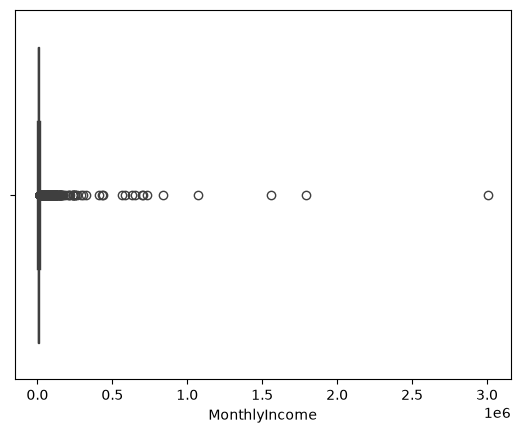

In [39]:
sns.boxplot(x=df['MonthlyIncome'])
plt.show()

In [40]:
print(df['MonthlyIncome'].skew())

114.04031794523321


In [41]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(missing_values=np.nan, strategy='median')
df[['MonthlyIncome']]=imputer.fit_transform(df[['MonthlyIncome']])    

In [42]:
df['MonthlyIncome']=np.log1p(df['MonthlyIncome']+1)

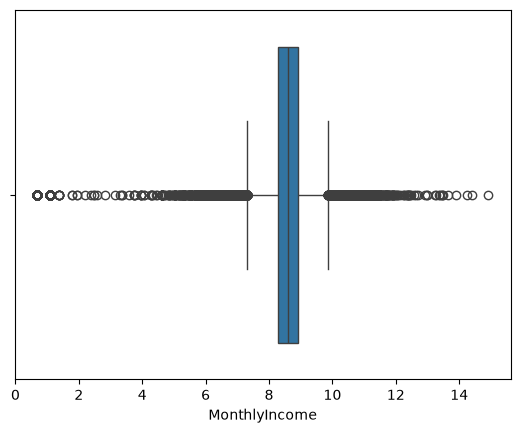

In [43]:
sns.boxplot(x=df['MonthlyIncome'])
plt.show()

In [44]:
print(df.isnull().sum())

SeriousDlqin2yrs                           0
RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                              0
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                      3924
dtype: int64


In [45]:
print(df['NumberOfDependents'].skew())

1.5882423788858833


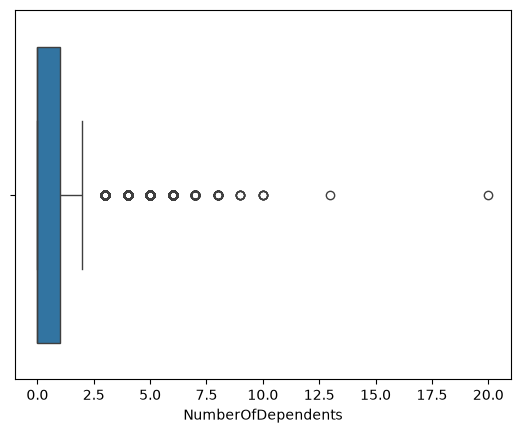

In [46]:
sns.boxplot(x=df['NumberOfDependents'])
plt.show()

In [47]:
df['NumberOfDependents'].value_counts().sort_index()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
9.0         5
10.0        5
13.0        1
20.0        1
Name: count, dtype: int64

In [48]:
df = df[df['NumberOfDependents'] <= 6]

In [50]:
print(df.duplicated().sum())

513


In [51]:
df.drop_duplicates(inplace=True)

In [62]:
for col in df.columns:
    print(f"{col} skewness: {df[col].skew()}")


SeriousDlqin2yrs skewness: 3.446852058033708
RevolvingUtilizationOfUnsecuredLines skewness: 0.8800300276854058
age skewness: 0.1923661426135192
NumberOfTime30-59DaysPastDueNotWorse skewness: 25.042443382008866
DebtRatio skewness: 101.26650937579006
MonthlyIncome skewness: -4.555945237644784
NumberOfOpenCreditLinesAndLoans skewness: 1.2215977641791278
NumberOfTimes90DaysLate skewness: 25.732468877662633
NumberRealEstateLoansOrLines skewness: 3.4897651343937204
NumberOfTime60-89DaysPastDueNotWorse skewness: 26.07937674322059
NumberOfDependents skewness: 1.4646985872379328


In [53]:
print(df[df['age'] < 18]['age'].value_counts().sort_index())

age
0    1
Name: count, dtype: int64


In [54]:
df = df[df['age'] != 0]

In [55]:
print(df.columns)

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')


In [60]:
print((df['RevolvingUtilizationOfUnsecuredLines'] > 1).value_counts().sort_index())

RevolvingUtilizationOfUnsecuredLines
False    142218
True       3257
Name: count, dtype: int64


In [61]:
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1)

print(df['RevolvingUtilizationOfUnsecuredLines'].describe())

count    145475.000000
mean          0.320801
std           0.348237
min           0.000000
25%           0.031199
50%           0.158751
75%           0.561072
max           1.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [63]:
cap_debt = df['DebtRatio'].quantile(0.9)
print("Cap value:", cap_debt)

df['DebtRatio'] = df['DebtRatio'].clip(upper=cap_debt)

print(df['DebtRatio'].describe())

Cap value: 1150.0
count    145475.000000
mean        146.532629
std         365.282986
min           0.000000
25%           0.173934
50%           0.359141
75%           0.770943
max        1150.000000
Name: DebtRatio, dtype: float64


In [66]:
print(df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index())

NumberOfTime30-59DaysPastDueNotWorse
0     121949
1      15735
2       4533
3       1740
4        735
5        339
6        138
7         54
8         25
9         11
10         4
11         1
12         2
13         1
96         5
98       203
Name: count, dtype: int64


In [67]:
df=df[df['NumberOfTime30-59DaysPastDueNotWorse'] <= 10]

In [68]:
print(df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index())

NumberOfTime60-89DaysPastDueNotWorse
0     138044
1       5641
2       1102
3        311
4        105
5         32
6         16
7          8
8          2
9          1
11         1
Name: count, dtype: int64


In [69]:
df=df[df['NumberOfTime60-89DaysPastDueNotWorse'] <= 8]

In [71]:
print(df['NumberOfTimes90DaysLate'].value_counts().sort_index())

NumberOfTimes90DaysLate
0     137368
1       5122
2       1520
3        654
4        289
5        128
6         79
7         37
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
Name: count, dtype: int64


In [73]:
print(df['SeriousDlqin2yrs'].value_counts())

SeriousDlqin2yrs
0    135566
1      9695
Name: count, dtype: int64


In [74]:
x=df.drop(columns=['SeriousDlqin2yrs'])
y=df['SeriousDlqin2yrs']


In [81]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [82]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

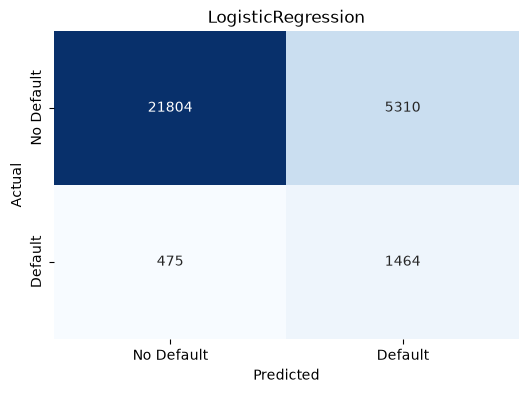

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27114
           1       0.22      0.76      0.34      1939

    accuracy                           0.80     29053
   macro avg       0.60      0.78      0.61     29053
weighted avg       0.93      0.80      0.85     29053



In [91]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42,class_weight='balanced')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import  confusion_matrix,classification_report
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('LogisticRegression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))


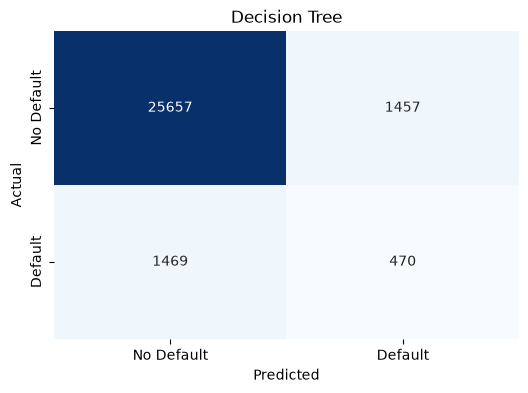

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     27114
           1       0.24      0.24      0.24      1939

    accuracy                           0.90     29053
   macro avg       0.59      0.59      0.59     29053
weighted avg       0.90      0.90      0.90     29053



In [88]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))

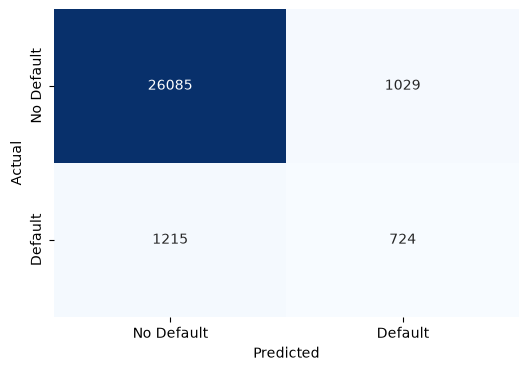

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     27114
           1       0.41      0.37      0.39      1939

    accuracy                           0.92     29053
   macro avg       0.68      0.67      0.68     29053
weighted avg       0.92      0.92      0.92     29053



In [87]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=200, n_jobs=-1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))

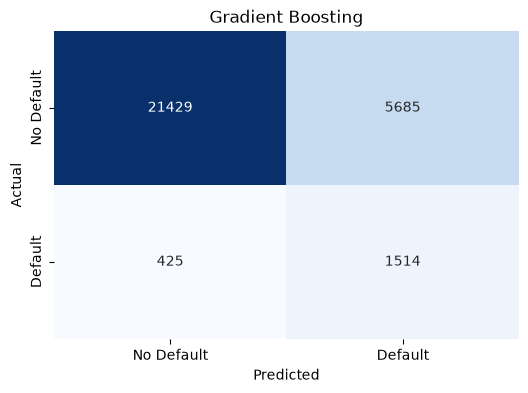

              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27114
           1       0.21      0.78      0.33      1939

    accuracy                           0.79     29053
   macro avg       0.60      0.79      0.60     29053
weighted avg       0.93      0.79      0.84     29053



In [90]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix, classification_report

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = GradientBoostingClassifier(random_state=42)
model.fit(x_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))

In [92]:
import joblib
joblib.dump(model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(x.columns), 'feature_names.pkl')

['feature_names.pkl']